# Progetto 3 — KNN vs SVM su dataset Wine ridotto con PCA

Implementare e confrontare due diversi algoritmi di classificazione, K-Nearest Neighbors (KNN) e Support Vector Machine (SVM), dopo aver ridotto la dimensionalità del dataset Wine utilizzando la PCA.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

## 1. Data Exploration & Preprocessing

- Caricamento e analisi del dataset, fornire un'analisi descrittiva iniziale (`df.describe()`, `df.dtypes`)
- Standardization delle feature (X) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria

In [4]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target
print(df.describe())
print(df.dtypes)


          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572359   
min         0.9

## 2. Data Dimensionality Reduction

- Applicare la PCA (Principal Component Analysis) sui dati standardizzati
- Ridurre la dimensionalità a 2 componenti principali (`n_components=2`) per facilitare la visualizzazione

In [9]:
X = df.drop(columns=['target'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


## 3. Addestramento & Valutazione

- Inizializzare due modelli:
  1. K-Nearest Neighbors (KNN) con `n_neighbors=5`
  2. Support Vector Machine (SVM) con `kernel='linear'`
- Addestrare entrambi i modelli utilizzando il dataset ridotto a 2 componenti
- Calcolare e stampare l'Accuracy Score di entrambi i modelli sull'intero set di dati ridotto

In [21]:
y = df["target"]
modello = KNeighborsClassifier(n_neighbors=5)
modello.fit(X_pca, y)
y_pred_knn = modello.predict(X_pca)
knn_corrette = (y_pred_knn == y).sum()
knn_errate = (y_pred_knn != y).sum()
knn_accuracy = knn_corrette / len(y)
print("Risultati KNN")
print("Etichette corrette:", knn_corrette)
print("Etichette errate:", knn_errate)
print("Accuracy:", knn_accuracy)

modello = SVC(kernel='linear')
modello.fit(X_pca, y)
y_pred_svc = modello.predict(X_pca)
svc_corrette = (y_pred_svc == y).sum()
svc_errate = (y_pred_svc != y).sum()
svc_accuracy = svc_corrette / len(y)
print("Risultati SVC")
print("Etichette corrette:", svc_corrette)
print("Etichette errate:", svc_errate)
print("Accuracy:", svc_accuracy)

Risultati KNN
Etichette corrette: 172
Etichette errate: 6
Accuracy: 0.9662921348314607
Risultati SVC
Etichette corrette: 173
Etichette errate: 5
Accuracy: 0.9719101123595506


## 4. Analisi & Visualizzazione

- Generare un grafico con due subplot per confrontare i risultati visivi
- Plottare i data points colorati in base alla loro classe di appartenenza (target)
- Visualizzare i decision boundary dei modelli (KNN e SVM)

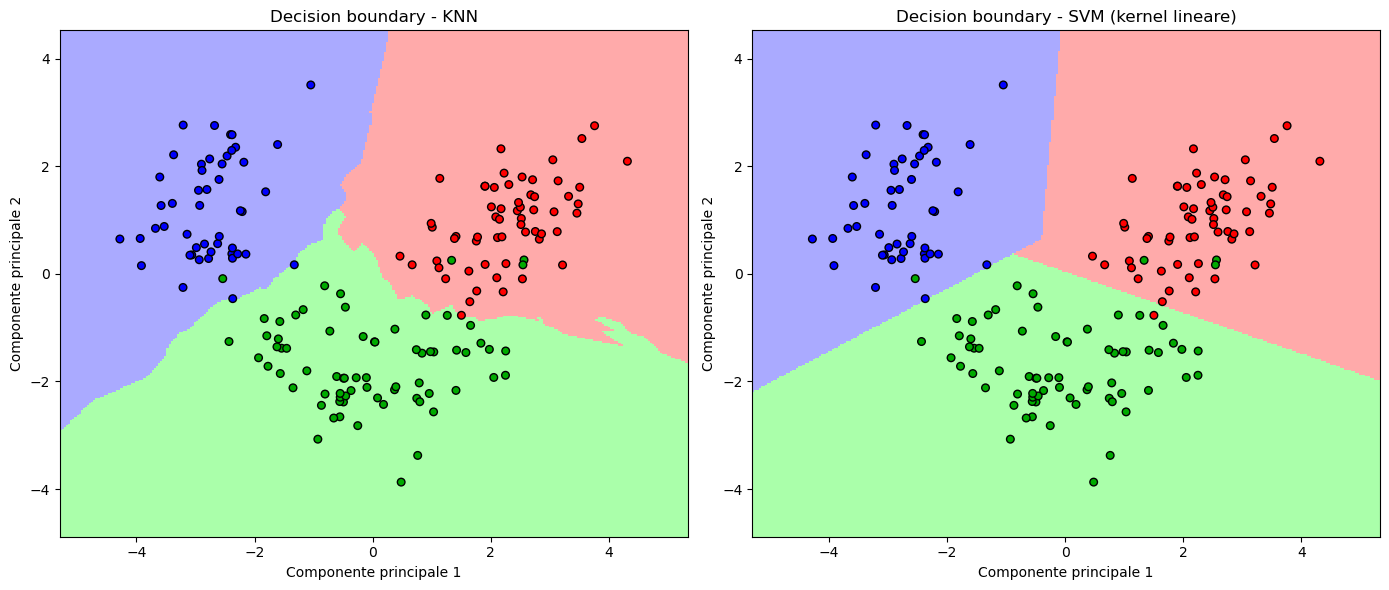

In [22]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_pca, y)

svm_model = SVC(kernel='linear')
svm_model.fit(X_pca, y)

cmap_light = ListedColormap(["#FFAAAA", "#AAFFAA", "#AAAAFF"])
cmap_bold = ListedColormap(["#FF0000", "#00AA00", "#0000FF"])

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, titolo in zip(axes, [knn_model, svm_model], ["KNN", "SVM (kernel lineare)"]):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.pcolormesh(xx, yy, Z, cmap=cmap_light)
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=30)
    ax.set_xlabel("Componente principale 1")
    ax.set_ylabel("Componente principale 2")
    ax.set_title(f"Decision boundary - {titolo}")

plt.tight_layout()
plt.show()